In [1]:
import pandas as pd
%pip install pyfaidx
from pyfaidx import Fasta
%pip install biopython
from Bio.Seq import Seq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.8 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving clinvar_data.tsv to clinvar_data.tsv
Saving clinvar_final.csv to clinvar_final.csv
Saving GR_Ch38.fa.fai to GR_Ch38.fa.fai
Saving hbb_seq.csv to hbb_seq.csv


In [3]:
# 1. Download the latest ClinVar VCF file directly from NCBI FTP servers (~200MB)
!wget -O clinvar.vcf.gz https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz

# 2. Verify the file downloaded correctly
import os
file_size = os.path.getsize('clinvar.vcf.gz') / (1024 * 1024)
print(f"clinvar.vcf.gz successfully downloaded! Size: {file_size:.2f} MB")

--2026-09-04 13:46:21--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.13, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 193427450 (184M) [application/x-gzip]
Saving to: ‘clinvar.vcf.gz’

clinvar.vcf.gz      100%[===================>] 184.47M  46.0MB/s    in 4.3s    

2026-09-04 13:46:25 (42.6 MB/s) - ‘clinvar.vcf.gz’ saved [193427450/193427450]

clinvar.vcf.gz successfully downloaded! Size: 184.47 MB


In [4]:
!pwd
!ls -la

/content
total 190364
drwxr-xr-x 1 root root      4096 Sep  4 13:46 .
drwxr-xr-x 1 root root      4096 Sep  4 13:37 ..
-rw-r--r-- 1 root root    571118 Sep  4 13:46 clinvar_data.tsv
-rw-r--r-- 1 root root    155587 Sep  4 13:46 clinvar_final.csv
-rw-r--r-- 1 root root 193427450 Aug 31 17:01 clinvar.vcf.gz
drwxr-xr-x 4 root root      4096 Aug 24 13:27 .config
-rw-r--r-- 1 root root        22 Sep  4 13:46 GR_Ch38.fa.fai
-rw-r--r-- 1 root root    747228 Sep  4 13:46 hbb_seq.csv
drwxr-xr-x 1 root root      4096 Aug 24 13:28 sample_data


In [5]:
import os
print(os.listdir('.'))
df=pd.read_table("clinvar_data.tsv")
print(df.shape)
print(df.columns)
print(df.info())
print(df['Type'].value_counts())
print(df['Molecular consequence'].value_counts())
print(df['Classification'].value_counts())

['.config', 'hbb_seq.csv', 'GR_Ch38.fa.fai', 'clinvar_final.csv', 'clinvar_data.tsv', 'clinvar.vcf.gz', 'sample_data']
(1962, 16)
Index(['Variation', 'Genes', 'Type', 'Condition', 'Classification',
       'Review status', 'Molecular consequence', 'Protein change',
       'Germline date last evaluated',
       'Somatic clinical impact date last evaluated',
       'Oncogenicity date last evaluated', 'GRCh37 Location',
       'GRCh38 Location', 'Variation ID', 'VCV accession', 'rs_ID'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1962 entries, 0 to 1961
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Variation                                    1962 non-null   object 
 1   Genes                                        1962 non-null   object 
 2   Type                                         1962 non-null   object 
 3   Conditi

In [6]:
df[df["Classification"] == "G: other"].head(20)

,Variation,Genes,Type,Condition,Classification,Review status,Molecular consequence,Protein change,Germline date last evaluated,Somatic clinical impact date last evaluated,Oncogenicity date last evaluated,GRCh37 Location,GRCh38 Location,Variation ID,VCV accession,rs_ID
89,NM_000518.5(HBB):c.441C>G (p.His147Gln),HBB|LOC107133510|LOC110006319,single nucleotide variant,HEMOGLOBIN KODAIRA II,G: other,no assertion criteria provided,missense variant,H147Q,2017/12/12,NaN,NaN,11:5246831,11:5225601,15601,VCV000015601,rs30640
90,NM_000518.5(HBB):c.441C>A (p.His147Gln),HBB|LOC107133510|LOC110006319,single nucleotide variant,HEMOGLOBIN KODAIRA,G: other,no assertion criteria provided,missense variant,H147Q,2016/07/20,NaN,NaN,11:5246831,11:5225601,15498,VCV000015498,rs30537
93,NM_000518.4(HBB):c.440A>G (p.His147Arg),HBB|LOC107133510|LOC110006319,single nucleotide variant,HEMOGLOBIN COCHIN-PORT ROYAL,G: other,no assertion criteria provided,missense variant,H147R,2017/12/12,NaN,NaN,11:5246832,11:5225602,15139,VCV000015139,rs30178
94,NM_000518.4(HBB):c.439C>T (p.His147Tyr),HBB|LOC107133510|LOC110006319,single nucleotide variant,HEMOGLOBIN BOLOGNA-ST. ORSOLA,G: other,no assertion criteria provided,missense variant,H147Y,2017/12/12,NaN,NaN,11:5246833,11:5225603,15577,VCV000015577,rs30616
98,NM_000518.5(HBB):c.436_437insCT (p.Tyr146fs),HBB|LOC107133510|LOC110006319,Insertion,HEMOGLOBIN CRANSTON,G: other,no assertion criteria provided,frameshift variant,Y146fs,1980/07/05,NaN,NaN,11:5246835,11:5225605,15145,VCV000015145,rs30184
104,NM_000518.5(HBB):c.434del (p.Lys145fs),HBB|LOC107133510|LOC110006319,Deletion,HEMOGLOBIN TRENTO,G: other,no assertion criteria provided,frameshift variant,K145fs,2017/12/12,NaN,NaN,11:5246838,11:5225608,15604,VCV000015604,rs30643
105,NM_000518.5(HBB):c.434A>T (p.Lys145Met),HBB|LOC107133510|LOC110006319,single nucleotide variant,HEMOGLOBIN BARBIZON,G: other,no assertion criteria provided,missense variant,K145M,2017/12/12,NaN,NaN,11:5246838,11:5225608,15576,VCV000015576,rs30615
107,NM_000518.4(HBB):c.[424C>G;433A>T],HBB|LOC107133510|LOC110006319|HBB|LOC107133510...,Haplotype,HEMOGLOBIN KOCHI,G: other,no assertion criteria provided,"nonsense, missense variant","K145*, L142V",2017/12/12,NaN,NaN,11:5246839,11:5225609,446749,VCV000446749,rs38409
108,NM_000518.5(HBB):c.425_433del (p.Leu142_Lys145...,HBB|LOC107133510|LOC110006319,Deletion,HEMOGLOBIN BIRMINGHAM,G: other,no assertion criteria provided,inframe_indel,NaN,2017/12/12,NaN,NaN,11:5246839,11:5225609,15478,VCV000015478,rs30517
109,NM_000518.4(HBB):c.433A>G (p.Lys145Glu),HBB|LOC107133510|LOC110006319,single nucleotide variant,HEMOGLOBIN MITO,G: other,no assertion criteria provided,missense variant,K145E,2017/12/12,NaN,NaN,11:5246839,11:5225609,15268,VCV000015268,rs30307


In [7]:
allowed_types=["single nucleotide variant","Deletion","Insertion","Indel"]
df=df[df['Type'].isin (allowed_types)].copy()

df.shape

(1815, 16)

In [8]:
allowed_classifications=["G: Pathogenic",
    "G: Likely pathogenic",
    "G: Pathogenic/Likely pathogenic",
    "G: Benign",
    "G: Likely benign",
    "G: Benign/Likely benign"]
df=df[df["Classification"].isin(allowed_classifications)].copy()
df.shape

(1213, 16)

In [9]:
pathogeneic_map={"G: Pathogenic":1,
    "G: Likely pathogenic":1,
    "G: Pathogenic/Likely pathogenic":1,
    "G: Benign":0,
    "G: Likely benign":0,
    "G: Benign/Likely benign":0}
df["Pathogenicity"]=df["Classification"].map(pathogeneic_map)
print(df['Pathogenicity'].value_counts)

<bound method IndexOpsMixin.value_counts of 3       1
4       1
5       1
6       1
7       1
       ..
1950    1
1951    1
1952    1
1953    1
1954    1
Name: Pathogenicity, Length: 1213, dtype: int64>


In [10]:
df.isnull().sum()
df["Molecular consequence"].value_counts(dropna=False)
pd.crosstab(df["Molecular consequence"], df["Pathogenicity"])

Pathogenicity,0,1
Molecular consequence,,
3 prime UTR variant,1,15
5 prime UTR variant,1,3
frameshift variant,0,100
"frameshift variant, initiator_codon_variant",0,2
inframe_deletion,0,2
inframe_indel,0,2
intron variant,699,17
missense variant,20,83
"missense variant, initiator_codon_variant",0,8


In [11]:
df["Type"].value_counts()
df.shape


(1213, 17)

In [12]:
df=df.dropna(subset=["GRCh38 Location"])
df.shape

(1192, 17)

In [13]:
df=df.dropna(subset=["Molecular consequence"])
df.shape
df.head()

,Variation,Genes,Type,Condition,Classification,Review status,Molecular consequence,Protein change,Germline date last evaluated,Somatic clinical impact date last evaluated,Oncogenicity date last evaluated,GRCh37 Location,GRCh38 Location,Variation ID,VCV accession,rs_ID,Pathogenicity
27,NM_000518.5(HBB):c.316_*132del (p.Leu106_Ter14...,HBB|LOC107133510|LOC110006319,Deletion,not provided,G: Pathogenic,"criteria provided, single submitter","stop lost, inframe_deletion",NaN,2019/12/16,NaN,NaN,11:5246696,11:5225466,862436,VCV000862436,rs838556,1
28,NM_000518.5(HBB):c.316-149_*132del,HBB|LOC107133510|LOC110006319,Deletion,not provided,G: Pathogenic,"criteria provided, single submitter",splice acceptor variant,NaN,2018/11/26,NaN,NaN,11:5246696,11:5225466,660167,VCV000660167,rs652208,1
29,NM_000518.5(HBB):c.*132C>T,HBB|LOC107133510|LOC110006319,single nucleotide variant,not provided,G: Likely pathogenic,"criteria provided, multiple submitters, no con...",3 prime UTR variant,NaN,2025/08/28,NaN,NaN,11:5246696,11:5225466,439130,VCV000439130,rs432668,1
35,NM_000518.5(HBB):c.*115_*116del,HBB|LOC107133510|LOC110006319,Deletion,not provided,G: Likely pathogenic,"criteria provided, single submitter",3 prime UTR variant,NaN,2025/10/03,NaN,NaN,11:5246712,11:5225482,869259,VCV000869259,rs857428,1
36,NM_000518.5(HBB):c.*116del,HBB|LOC107133510|LOC110006319,Deletion,BETA-PLUS-THALASSEMIA,G: Pathogenic,no assertion criteria provided,3 prime UTR variant,NaN,1992/06/01,NaN,NaN,11:5246712,11:5225482,15474,VCV000015474,rs30513,1


In [14]:
cols_to_drop = [
    'Variation',                                  # HGVS name string — see caution below
    'Condition',
    'Review status',
    'Protein change',
    'Germline date last evaluated',
    'Somatic clinical impact date last evaluated',
    'Oncogenicity date last evaluated',
    'GRCh37 Location',
    'rs_ID',
]

df = df.drop(columns=cols_to_drop)

df = df.rename(columns={
    'Genes': 'Gene',
    'Type': 'Variant type',
})
df.head()

,Gene,Variant type,Classification,Molecular consequence,GRCh38 Location,Variation ID,VCV accession,Pathogenicity
27,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,"stop lost, inframe_deletion",11:5225466,862436,VCV000862436,1
28,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,splice acceptor variant,11:5225466,660167,VCV000660167,1
29,HBB|LOC107133510|LOC110006319,single nucleotide variant,G: Likely pathogenic,3 prime UTR variant,11:5225466,439130,VCV000439130,1
35,HBB|LOC107133510|LOC110006319,Deletion,G: Likely pathogenic,3 prime UTR variant,11:5225482,869259,VCV000869259,1
36,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,3 prime UTR variant,11:5225482,15474,VCV000015474,1


In [15]:
consequence_map = {
    # Protein-truncating / splice-disrupting
    'frameshift variant': 'Protein-truncating / splice-disrupting',
    'frameshift variant, initiator_codon_variant': 'Protein-truncating / splice-disrupting',
    'frameshift variant, stop lost': 'Protein-truncating / splice-disrupting',
    'nonsense': 'Protein-truncating / splice-disrupting',
    'nonsense, inframe_insertion': 'Protein-truncating / splice-disrupting',
    'nonsense, initiator_codon_variant': 'Protein-truncating / splice-disrupting',
    'nonsense, missense variant': 'Protein-truncating / splice-disrupting',
    'splice donor variant': 'Protein-truncating / splice-disrupting',
    'splice acceptor variant': 'Protein-truncating / splice-disrupting',
    'stop lost, inframe_deletion': 'Protein-truncating / splice-disrupting',

    # Missense / in-frame coding
    'missense variant': 'Missense / in-frame coding',
    'missense variant, initiator_codon_variant': 'Missense / in-frame coding',
    'inframe_deletion': 'Missense / in-frame coding',
    'inframe_insertion': 'Missense / in-frame coding',
    'inframe_indel': 'Missense / in-frame coding',

    # Synonymous
    'synonymous variant': 'Synonymous',

    # UTR
    '3 prime UTR variant': 'UTR',
    '5 prime UTR variant': 'UTR',

    # Intron
    'intron variant': 'Intron',
}

# STEP 1 — create the column (this line MUST run before any check below)
df['Mutation type'] = df['Molecular consequence'].map(consequence_map)

# STEP 2 — now it's safe to check for unmapped values
unmapped = df[df['Mutation type'].isna()]['Molecular consequence'].unique()
print("Unmapped raw values:", unmapped)

# STEP 3 — confirm and view counts
assert len(unmapped) == 0, f"Add these to consequence_map: {unmapped}"
print(df['Mutation type'].value_counts())
df.shape

Unmapped raw values: []
Mutation type
Intron                                    716
Protein-truncating / splice-disrupting    167
Missense / in-frame coding                115
Synonymous                                102
UTR                                        20
Name: count, dtype: int64


(1120, 9)

In [16]:
df.head()

,Gene,Variant type,Classification,Molecular consequence,GRCh38 Location,Variation ID,VCV accession,Pathogenicity,Mutation type
27,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,"stop lost, inframe_deletion",11:5225466,862436,VCV000862436,1,Protein-truncating / splice-disrupting
28,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,splice acceptor variant,11:5225466,660167,VCV000660167,1,Protein-truncating / splice-disrupting
29,HBB|LOC107133510|LOC110006319,single nucleotide variant,G: Likely pathogenic,3 prime UTR variant,11:5225466,439130,VCV000439130,1,UTR
35,HBB|LOC107133510|LOC110006319,Deletion,G: Likely pathogenic,3 prime UTR variant,11:5225482,869259,VCV000869259,1,UTR
36,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,3 prime UTR variant,11:5225482,15474,VCV000015474,1,UTR


In [17]:
df.to_csv("clinvar_final.csv")
df[['Chrom','pos']]=df['GRCh38 Location'].str.split(':',expand=True)
df.head()

,Gene,Variant type,Classification,Molecular consequence,GRCh38 Location,Variation ID,VCV accession,Pathogenicity,Mutation type,Chrom,pos
27,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,"stop lost, inframe_deletion",11:5225466,862436,VCV000862436,1,Protein-truncating / splice-disrupting,11,5225466
28,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,splice acceptor variant,11:5225466,660167,VCV000660167,1,Protein-truncating / splice-disrupting,11,5225466
29,HBB|LOC107133510|LOC110006319,single nucleotide variant,G: Likely pathogenic,3 prime UTR variant,11:5225466,439130,VCV000439130,1,UTR,11,5225466
35,HBB|LOC107133510|LOC110006319,Deletion,G: Likely pathogenic,3 prime UTR variant,11:5225482,869259,VCV000869259,1,UTR,11,5225482
36,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,3 prime UTR variant,11:5225482,15474,VCV000015474,1,UTR,11,5225482


In [18]:
vcf_cols = ['CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO']
vcf = pd.read_csv('clinvar.vcf.gz', sep='\t', comment='#', names=vcf_cols,
                   compression='gzip', usecols=['CHROM','POS','ID','REF','ALT'])
df = df.merge(vcf, left_on='Variation ID', right_on='ID', how='left')
print(df['REF'].isna().sum(), "rows failed to match — check these separately")

/tmp/ipykernel_1923/3719750922.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  vcf = pd.read_csv('clinvar.vcf.gz', sep='\t', comment='#', names=vcf_cols,


0 rows failed to match — check these separately


In [21]:
# 1. Download Chromosome 11 reference sequence for GRCh38 (~10MB) directly in Colab
!wget -O chr11.fa.gz http://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr11.fa.gz

# 2. Decompress the downloaded chromosome file
!gunzip -f chr11.fa.gz

# 3. Rename the chromosome file to match your pipeline code expectation

os.rename("chr11.fa", "Gr_Ch38.fa")

print("Gr_Ch38.fa successfully generated for Chromosome 11!")
genome = Fasta('Gr_Ch38.fa')
df['pos'] = df['pos'].astype(int)
FLANK = 250
BUFFER = 20

def get_alt_window(row):
    chrom = str(row['CHROM'])
    pos = int(row['POS'])
    ref = str(row['REF'])
    alt = str(row['ALT'])

    # Fix: UCSC FASTA uses 'chr11', ClinVar dataframe uses '11'
    chrom_key = chrom if chrom in genome else f"chr{chrom}"
    if chrom_key not in genome:
        return None

    fetch_start = pos - FLANK - BUFFER
    fetch_end   = pos + FLANK + max(len(ref), len(alt)) + BUFFER

    region = genome[chrom_key][fetch_start-1:fetch_end].seq.upper()

    offset = pos - fetch_start
    if region[offset:offset+len(ref)] != ref:
        return None  # reference mismatch — skip row

    alt_region = region[:offset] + alt + region[offset+len(ref):]
    center = offset + len(ref)//2
    return alt_region[center-FLANK : center+FLANK+1]

df['alt_window'] = df.apply(get_alt_window, axis=1)
print(f"Sequence extraction complete! Extracted {df['alt_window'].notna().sum()} valid sequences.")

--2026-09-04 13:50:06--  http://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr11.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 43168911 (41M) [application/x-gzip]
Saving to: ‘chr11.fa.gz’

chr11.fa.gz         100%[===================>]  41.17M  92.1MB/s    in 0.4s    

2026-09-04 13:50:06 (92.1 MB/s) - ‘chr11.fa.gz’ saved [43168911/43168911]

Gr_Ch38.fa successfully generated for Chromosome 11!
Sequence extraction complete! Extracted 1120 valid sequences.


In [22]:
df.head()

,Gene,Variant type,Classification,Molecular consequence,GRCh38 Location,Variation ID,VCV accession,Pathogenicity,Mutation type,Chrom,pos,CHROM,POS,ID,REF,ALT,alt_window
0,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,"stop lost, inframe_deletion",11:5225466,862436,VCV000862436,1,Protein-truncating / splice-disrupting,11,5225466,11,5225465,862436,TGCAATGAAAATAAATGTTTTTTATTAGGCAGAATCCAGATGCTCA...,T,AAGATATAGTGTATTTTCCCAAGGTTTGAACTAGCTCTTCATTTCT...
1,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,splice acceptor variant,11:5225466,660167,VCV000660167,1,Protein-truncating / splice-disrupting,11,5225466,11,5225465,660167,TGCAATGAAAATAAATGTTTTTTATTAGGCAGAATCCAGATGCTCA...,T,ATTCCCTTTTTAGTAAAATATTCAGAAATAATTTAAATACATCATT...
2,HBB|LOC107133510|LOC110006319,single nucleotide variant,G: Likely pathogenic,3 prime UTR variant,11:5225466,439130,VCV000439130,1,UTR,11,5225466,11,5225466,439130,G,A,AGCAAAACTTTAACCTCCAAATCAAGCCTCTACTTGAATCCTTTTC...
3,HBB|LOC107133510|LOC110006319,Deletion,G: Likely pathogenic,3 prime UTR variant,11:5225482,869259,VCV000869259,1,UTR,11,5225482,11,5225481,869259,GTT,G,CCAAATCAAGCCTCTACTTGAATCCTTTTCTGAGGGATGAATAAGG...
4,HBB|LOC107133510|LOC110006319,Deletion,G: Pathogenic,3 prime UTR variant,11:5225482,15474,VCV000015474,1,UTR,11,5225482,11,5225481,15474,GT,G,CCAAATCAAGCCTCTACTTGAATCCTTTTCTGAGGGATGAATAAGG...


In [23]:
df = df[df["alt_window"].str.len() == 501].copy()
print(len(df))

print(df["alt_window"].str.len().value_counts())

print(df["Pathogenicity"].value_counts())

print(df["Mutation type"].value_counts())

1114
alt_window
501    1114
Name: count, dtype: int64
Pathogenicity
0    820
1    294
Name: count, dtype: int64
Mutation type
Intron                                    716
Protein-truncating / splice-disrupting    162
Missense / in-frame coding                114
Synonymous                                102
UTR                                        20
Name: count, dtype: int64


In [24]:

df = df.rename(columns={
    "CHROM": "Chromosome",
    "POS": "Position",
    "alt_window": "Sequence"
})
df.to_csv("hbb_seq.csv", index=False)
df.head()
print(df["Sequence"].isna().sum())
print(df["Pathogenicity"].value_counts())
print()
print(df["Mutation type"].value_counts())

0
Pathogenicity
0    820
1    294
Name: count, dtype: int64

Mutation type
Intron                                    716
Protein-truncating / splice-disrupting    162
Missense / in-frame coding                114
Synonymous                                102
UTR                                        20
Name: count, dtype: int64


DATA SPLITTING & DANBERT2 LOADING

In [25]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

In [26]:
#labeling mutation type to numeric labels(0-4)
label_encoder = LabelEncoder()
df['mutation_label'] = label_encoder.fit_transform(df['Mutation type'])

In [27]:
#splitting train and test data
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Pathogenicity']
)

In [28]:
tokenizer = AutoTokenizer.from_pretrained("quietflamingo/dnabert2-no-flashattention", trust_remote_code=True)

config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

configuration_bert.py:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- configuration_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/168k [00:00<?, ?B/s]

In [29]:
#Define Custom PyTorch Dataset Class
class hbbdataset(Dataset):
    def __init__(self, df, tokenizer, max_length=501):
        self.sequences = df['Sequence'].tolist()
        self.pathogenicity_labels = df['Pathogenicity'].tolist()
        self.mutation_labels = df['mutation_label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]

        # Convert DNA string to token IDs
        encoding = self.tokenizer(
            seq,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'pathogenicity': torch.tensor(self.pathogenicity_labels[idx], dtype=torch.long),
            'mutation_type': torch.tensor(self.mutation_labels[idx], dtype=torch.long)
        }

In [30]:
#Instantiate Datasets and DataLoaders
train_dataset = hbbdataset(train_df, tokenizer)
test_dataset = hbbdataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Data Preparation Complete:")
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")
print(f"Mutation Classes Mapped: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

Data Preparation Complete:
Train samples: 891 | Test samples: 223
Mutation Classes Mapped: {'Intron': 0, 'Missense / in-frame coding': 1, 'Protein-truncating / splice-disrupting': 2, 'Synonymous': 3, 'UTR': 4}


In [31]:
import os
from huggingface_hub import snapshot_download

# Disable Xet parallel locks and set extended timeout limits
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"

print("Downloading model weights with resume support...")
snapshot_download(
    repo_id="quietflamingo/dnabert2-no-flashattention",
    resume_download=True
)
print("Model download complete!")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Model download complete!


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoConfig, AutoTokenizer
from transformers.dynamic_module_utils import get_class_from_dynamic_module
from huggingface_hub import hf_hub_download

# 1. Device Selection (MPS for M3 Mac -> CUDA -> CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Target Device: MPS (Apple Silicon GPU Acceleration)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Target Device: CUDA")
else:
    device = torch.device("cpu")
    print("Target Device: CPU")

MODEL_NAME = "quietflamingo/dnabert2-no-flashattention"

# 2. Load Config & Explicitly Set Tokenizer IDs
config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

config.pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 3

# Disable FlashAttention / Triton checks in config
if hasattr(config, "use_triton"):
    config.use_triton = False

# 3. Import dynamic BertModel class directly
BertModelClass = get_class_from_dynamic_module(
    "bert_layers.BertModel",
    MODEL_NAME
)

# 4. Download weights path directly to bypass Meta-Device Context
weights_path = hf_hub_download(repo_id=MODEL_NAME, filename="pytorch_model.bin")

def load_dnabert_encoder(config, weights_path):
    # Instantiate raw model architecture on CPU without meta context
    model = BertModelClass(config)
    state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
    model.load_state_dict(state_dict, strict=False)
    return model


# 5. Single-Task Baseline Model (Pathogenicity Only)
class SingleTaskDNABERT(nn.Module):
    def __init__(self, config=config, weights_path=weights_path):
        super(SingleTaskDNABERT, self).__init__()
        self.encoder = load_dnabert_encoder(config, weights_path)
        self.pathogenicity_head = nn.Linear(config.hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs[0]  # Shape: [batch_size, seq_len, 768]
        mask = attention_mask.unsqueeze(-1).float()
        pooled_output = (hidden_states * mask).sum(1) / mask.sum(1).clamp(min=1e-9)  # Masked mean pooling
        patho_logits = self.pathogenicity_head(pooled_output)
        return patho_logits


# 6. Multi-Task Model (Pathogenicity + Mutation Type)
class MultiTaskDNABERT(nn.Module):
    def __init__(self, config=config, weights_path=weights_path, num_mutation_classes=5):
        super(MultiTaskDNABERT, self).__init__()
        self.encoder = load_dnabert_encoder(config, weights_path)
        hidden_size = config.hidden_size

        # Head 1: Pathogenicity (Binary: 2 output classes)
        self.pathogenicity_head = nn.Linear(hidden_size, 2)

        # Head 2: Mutation Type (Auxiliary: 5 output classes)
        self.mutation_head = nn.Linear(hidden_size, num_mutation_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs[0]  # Shape: [batch_size, seq_len, 768]
        mask = attention_mask.unsqueeze(-1).float()
        pooled_output = (hidden_states * mask).sum(1) / mask.sum(1).clamp(min=1e-9)  # Masked mean pooling

        patho_logits = self.pathogenicity_head(pooled_output)
        mut_logits = self.mutation_head(pooled_output)

        return patho_logits, mut_logits


# 7. Instantiate and move directly to Apple Silicon MPS GPU
single_model = SingleTaskDNABERT(config=config, weights_path=weights_path).to(device)
multi_model = MultiTaskDNABERT(config=config, weights_path=weights_path).to(device)



Target Device: CUDA


[transformers] A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


## VALIDATION & ROBUSTNESS PIPELINE (A–G)

Cells below replace the old single-run training (previously Cells 28–30, removed here). Run top to bottom.

### G — Verify pretrained encoder weights loaded correctly

In [33]:
# G. Verify DNABERT-2 encoder weights loaded correctly (not silently skipped)
def load_dnabert_encoder_verbose(config, weights_path):
    model = BertModelClass(config)
    state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
    load_result = model.load_state_dict(state_dict, strict=False)
    print(f"Missing keys ({len(load_result.missing_keys)}):", load_result.missing_keys[:20])
    print(f"Unexpected keys ({len(load_result.unexpected_keys)}):", load_result.unexpected_keys[:20])
    encoder_missing = [k for k in load_result.missing_keys
                        if not k.startswith(('pathogenicity_head', 'mutation_head'))]
    if encoder_missing:
        print("WARNING: encoder-body weights missing —", encoder_missing[:10])
        print("Pretrained weights may NOT have loaded correctly into the encoder.")
    else:
        print("OK: no encoder-body weights missing. Pretrained DNABERT-2 loaded successfully.")
    return model

_ = load_dnabert_encoder_verbose(config, weights_path)


Missing keys (138): ['embeddings.word_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.LayerNorm.weight', 'embeddings.LayerNorm.bias', 'encoder.layer.0.attention.self.Wqkv.weight', 'encoder.layer.0.attention.self.Wqkv.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.mlp.gated_layers.weight', 'encoder.layer.0.mlp.wo.weight', 'encoder.layer.0.mlp.wo.bias', 'encoder.layer.0.mlp.layernorm.weight', 'encoder.layer.0.mlp.layernorm.bias', 'encoder.layer.1.attention.self.Wqkv.weight', 'encoder.layer.1.attention.self.Wqkv.bias', 'encoder.layer.1.attention.output.dense.weight', 'encoder.layer.1.attention.output.dense.bias', 'encoder.layer.1.attention.output.LayerNorm.weight']
Unexpected keys (142): ['bert.embeddings.LayerNorm.bias', 'bert.embeddings.LayerNorm.weight', 'bert.embeddings.token_type_emb

### F — Duplicate / leakage check on the full dataset

In [34]:
# F. Duplicate rows check on the full dataset
print("Duplicate Variation IDs in full dataset:", df['Variation ID'].duplicated().sum())
print("Duplicate Sequences in full dataset:", df['Sequence'].duplicated().sum())

def check_split_leakage(train_df, test_df, val_df=None):
    train_ids, test_ids = set(train_df['Variation ID']), set(test_df['Variation ID'])
    print(f"Train/Test Variation ID overlap: {len(train_ids & test_ids)}")
    if val_df is not None:
        val_ids = set(val_df['Variation ID'])
        print(f"Train/Val overlap: {len(train_ids & val_ids)}")
        print(f"Val/Test overlap: {len(val_ids & test_ids)}")
    train_seqs, test_seqs = set(train_df['Sequence']), set(test_df['Sequence'])
    print(f"Train/Test Sequence overlap: {len(train_seqs & test_seqs)}")


Duplicate Variation IDs in full dataset: 0
Duplicate Sequences in full dataset: 0


### New 70/10/20 train/val/test split (stratified on Pathogenicity + Mutation type)
This replaces the original 80/20 split (old Cell 22).

In [35]:
df['strat_col'] = df['Pathogenicity'].astype(str) + "_" + df['Mutation type'].astype(str)

vc = df['strat_col'].value_counts()
print("Rare strata (<5 samples) — stratification may fall back for these:\n", vc[vc < 5])

try:
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['strat_col'])
    val_df, test_df = train_test_split(temp_df, test_size=(2/3), random_state=42, stratify=temp_df['strat_col'])
except ValueError as e:
    print("Combined stratification failed, falling back to Pathogenicity-only:", e)
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['Pathogenicity'])
    val_df, test_df = train_test_split(temp_df, test_size=(2/3), random_state=42, stratify=temp_df['Pathogenicity'])

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
check_split_leakage(train_df, test_df, val_df)

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{name} Mutation type counts:\n{split['Mutation type'].value_counts()}")

train_dataset = hbbdataset(train_df, tokenizer)
val_dataset   = hbbdataset(val_df, tokenizer)
test_dataset  = hbbdataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

test_df_reset = test_df.reset_index(drop=True)
class_names = list(label_encoder.classes_)


Rare strata (<5 samples) — stratification may fall back for these:
 strat_col
1_Synonymous    3
0_UTR           2
Name: count, dtype: int64
Combined stratification failed, falling back to Pathogenicity-only: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

Train: 779 | Val: 111 | Test: 224
Train/Test Variation ID overlap: 0
Train/Val overlap: 0
Val/Test overlap: 0
Train/Test Sequence overlap: 0

Train Mutation type counts:
Mutation type
Intron                                    499
Protein-truncating / splice-disrupting    115
Missense / in-frame coding                 87
Synonymous                                 68
UTR                                        10
Name: count, dtype: int64

Val Mutation type counts:
Mutation type
Intron                                    76
Protein-truncating / splice-disrupting    12
Missense / in-frame coding                11
Synonymous                               

### Reusable training / evaluation functions

In [41]:
import numpy as np
import torch.optim as optim
import random
from sklearn.metrics import (roc_auc_score, f1_score, matthews_corrcoef, accuracy_score,
                              confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def get_class_weights(labels):
    classes = np.unique(labels)
    w = compute_class_weight('balanced', classes=classes, y=labels)
    return torch.tensor(w, dtype=torch.float)

def train_single_task(seed, epochs=5, lr=2e-5, verbose=False):
    set_seed(seed)
    model = SingleTaskDNABERT(config=config, weights_path=weights_path).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['pathogenicity'].to(device)
            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if verbose:
            print(f"  [seed {seed}] single-task epoch {epoch+1}/{epochs} loss {total_loss/len(train_loader):.4f}")
    return model

def train_multi_task(seed, beta, epochs=5, lr=2e-5, use_class_weights=True, verbose=False):
    set_seed(seed)
    model = MultiTaskDNABERT(config=config, weights_path=weights_path).to(device)
    if use_class_weights:
        patho_w = get_class_weights(train_df['Pathogenicity'].values).to(device)
        mut_w = get_class_weights(train_df['mutation_label'].values).to(device)
    else:
        patho_w, mut_w = None, None
    criterion_patho = nn.CrossEntropyLoss(weight=patho_w)
    criterion_mut = nn.CrossEntropyLoss(weight=mut_w)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            patho_labels = batch['pathogenicity'].to(device)
            mut_labels = batch['mutation_type'].to(device)
            optimizer.zero_grad()
            patho_logits, mut_logits = model(input_ids, attention_mask)
            loss_p = criterion_patho(patho_logits, patho_labels)
            loss_m = criterion_mut(mut_logits, mut_labels)
            joint_loss = loss_p + beta * loss_m
            joint_loss.backward()
            optimizer.step()
            total_loss += joint_loss.item()
        if verbose:
            print(f"  [seed {seed}, beta {beta}] multi-task epoch {epoch+1}/{epochs} loss {total_loss/len(train_loader):.4f}")
    return model

def evaluate_pathogenicity(model, loader, is_multi_task):
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['pathogenicity'].to(device)
            logits = model(input_ids, attention_mask)
            logits = logits[0] if is_multi_task else logits
            prob = torch.softmax(logits, dim=1)[:, 1]
            y_true.extend(labels.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
    y_true, y_prob = np.array(y_true), np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = {
        'auroc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=[0, 1])
    }
    return y_true, y_pred, y_prob, metrics

def evaluate_mutation_type(model, loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['mutation_type'].to(device)
            _, mut_logits = model(input_ids, attention_mask)
            preds = torch.argmax(mut_logits, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'report': classification_report(y_true, y_pred, target_names=class_names,
                                         output_dict=True, zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    }


### A — Beta ablation on the validation set

**Sanity check first**: temporarily set `epochs=1` and `beta_values=[0.0, 0.5]` to confirm the pipeline runs end-to-end before committing to the full run.

In [43]:
beta_values = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5]
ablation_results = []

for beta in beta_values:
    model = train_multi_task(seed=42, beta=beta, epochs=5, verbose=False)
    _, _, _, val_patho = evaluate_pathogenicity(model, val_loader, is_multi_task=True)
    val_mut = evaluate_mutation_type(model, val_loader, class_names)
    ablation_results.append({
        'beta': beta, 'val_auroc': val_patho['auroc'], 'val_f1': val_patho['f1'],
        'val_mcc': val_patho['mcc'], 'val_mut_macro_f1': val_mut['macro_f1']
    })
    print(f"beta={beta:.2f} | AUROC={val_patho['auroc']:.4f} | F1={val_patho['f1']:.4f} "
          f"| MCC={val_patho['mcc']:.4f} | Mut-MacroF1={val_mut['macro_f1']:.4f}")

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv("beta_ablation_val_results.csv", index=False)
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
plt.plot(ablation_df['beta'], ablation_df['val_auroc'], marker='o', label='AUROC')
plt.plot(ablation_df['beta'], ablation_df['val_f1'], marker='s', label='F1')
plt.plot(ablation_df['beta'], ablation_df['val_mcc'], marker='^', label='MCC')
plt.xlabel('Auxiliary loss weight (beta)'); plt.ylabel('Validation metric')
plt.title('Beta Ablation: Auxiliary Mutation-Type Loss vs. Pathogenicity Performance')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("beta_ablation_curve.png", dpi=300); plt.show()

BEST_BETA = ablation_df.loc[ablation_df['val_mcc'].idxmax(), 'beta']
print(f"\nSelected beta (best validation MCC): {BEST_BETA}")


/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


beta=0.00 | AUROC=0.8810 | F1=0.7250 | MCC=0.6450 | Mut-MacroF1=0.0331


/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


beta=0.10 | AUROC=0.9024 | F1=0.7250 | MCC=0.6450 | Mut-MacroF1=0.2527


/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


...

/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


beta=1.00 | AUROC=0.9029 | F1=0.7342 | MCC=0.6569 | Mut-MacroF1=0.4581


/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


beta=1.50 | AUROC=0.9188 | F1=0.7342 | MCC=0.6569 | Mut-MacroF1=0.4581


NameError: name 'plt' is not defined

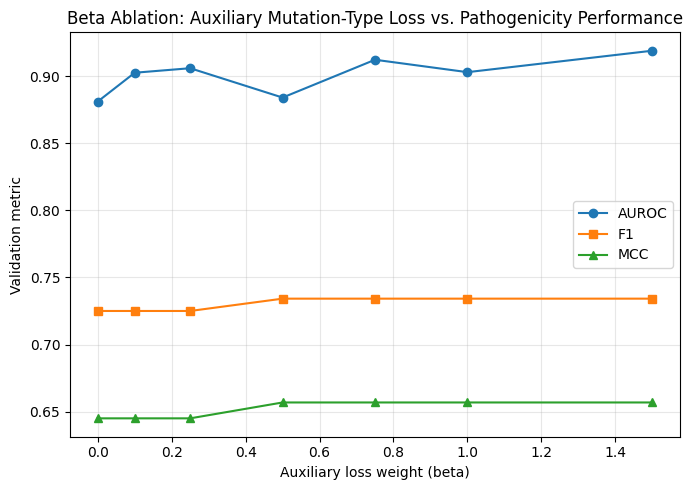


Selected beta (best validation MCC): 0.5


In [44]:
import matplotlib.pyplot as plt

# 1. Plot the ablation curve from existing in-memory results
plt.figure(figsize=(7, 5))
plt.plot(ablation_df['beta'], ablation_df['val_auroc'], marker='o', label='AUROC')
plt.plot(ablation_df['beta'], ablation_df['val_f1'], marker='s', label='F1')
plt.plot(ablation_df['beta'], ablation_df['val_mcc'], marker='^', label='MCC')
plt.xlabel('Auxiliary loss weight (beta)')
plt.ylabel('Validation metric')
plt.title('Beta Ablation: Auxiliary Mutation-Type Loss vs. Pathogenicity Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("beta_ablation_curve.png", dpi=300)
plt.show()

# 2. Extract best beta for the 5-seed run
BEST_BETA = ablation_df.loc[ablation_df['val_mcc'].idxmax(), 'beta']
print(f"\nSelected beta (best validation MCC): {BEST_BETA}")

### B / C / D — 5-seed runs (baseline + multi-task), collecting mutation-task and per-class results together

**Sanity check first**: temporarily set `epochs=1` and `SEEDS=[0]` to confirm this runs clean before the full 5-seed job.

In [45]:
SEEDS = [0, 1, 2, 3, 4]
baseline_results, mtl_results = [], []
baseline_cms, mtl_cms = [], []
mtl_mut_results, mtl_mut_cms = [], []
per_class_patho_records = []
last_mut_eval = None

for seed in SEEDS:
    print(f"\n===== SEED {seed} =====")

    # Baseline (single-task)
    base_model = train_single_task(seed=seed, epochs=5, verbose=False)
    y_true_b, y_pred_b, y_prob_b, base_metrics = evaluate_pathogenicity(base_model, test_loader, is_multi_task=False)
    baseline_results.append({'seed': seed, 'auroc': base_metrics['auroc'],
                              'f1': base_metrics['f1'], 'mcc': base_metrics['mcc']})
    baseline_cms.append(base_metrics['confusion_matrix'])

    # Multi-task at selected beta
    mtl_model = train_multi_task(seed=seed, beta=BEST_BETA, epochs=5, verbose=False)
    y_true_m, y_pred_m, y_prob_m, mtl_metrics = evaluate_pathogenicity(mtl_model, test_loader, is_multi_task=True)
    mtl_results.append({'seed': seed, 'auroc': mtl_metrics['auroc'],
                         'f1': mtl_metrics['f1'], 'mcc': mtl_metrics['mcc']})
    mtl_cms.append(mtl_metrics['confusion_matrix'])

    # D: mutation-type task evaluation
    mut_eval = evaluate_mutation_type(mtl_model, test_loader, class_names)
    last_mut_eval = mut_eval
    mtl_mut_results.append({'seed': seed, 'accuracy': mut_eval['accuracy'], 'macro_f1': mut_eval['macro_f1']})
    mtl_mut_cms.append(mut_eval['confusion_matrix'])

    # C: per-mutation-class pathogenicity comparison
    mut_types_test = test_df_reset['Mutation type'].values
    for mtype in class_names:
        idx = np.where(mut_types_test == mtype)[0]
        if len(idx) < 2 or len(np.unique(y_true_b[idx])) < 2:
            base_auroc = mtl_auroc = np.nan
        else:
            base_auroc = roc_auc_score(y_true_b[idx], y_prob_b[idx])
            mtl_auroc = roc_auc_score(y_true_m[idx], y_prob_m[idx])
        per_class_patho_records.append({
            'seed': seed, 'mutation_type': mtype, 'n_test': len(idx),
            'baseline_auroc': base_auroc, 'mtl_auroc': mtl_auroc,
            'baseline_f1': f1_score(y_true_b[idx], y_pred_b[idx], zero_division=0) if len(idx) else np.nan,
            'mtl_f1': f1_score(y_true_m[idx], y_pred_m[idx], zero_division=0) if len(idx) else np.nan,
        })

print("\nAll 5 seeds complete.")



===== SEED 0 =====


/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(



===== SEED 1 =====


/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(



===== SEED 2 =====


...


===== SEED 3 =====


/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(



===== SEED 4 =====


/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(



All 5 seeds complete.


### Aggregate B — mean ± std across seeds, plus paired significance test

In [46]:
baseline_df = pd.DataFrame(baseline_results)
mtl_df = pd.DataFrame(mtl_results)

print("=== Baseline (Single-Task) — mean ± std across 5 seeds ===")
print(baseline_df[['auroc', 'f1', 'mcc']].agg(['mean', 'std']))

print(f"\n=== Multi-Task (beta={BEST_BETA}) — mean ± std across 5 seeds ===")
print(mtl_df[['auroc', 'f1', 'mcc']].agg(['mean', 'std']))

baseline_df.to_csv("baseline_5seed_results.csv", index=False)
mtl_df.to_csv("mtl_5seed_results.csv", index=False)

from scipy.stats import ttest_rel
print("\nPaired t-test (n=5 seeds, weak power — treat as indicative, not definitive):")
for metric in ['auroc', 'f1', 'mcc']:
    t_stat, p_val = ttest_rel(mtl_df[metric], baseline_df[metric])
    print(f"  {metric.upper()}: p={p_val:.4f} | MTL mean={mtl_df[metric].mean():.4f} "
          f"vs Baseline mean={baseline_df[metric].mean():.4f}")


=== Baseline (Single-Task) — mean ± std across 5 seeds ===
         auroc        f1       mcc
mean  0.897442  0.670587  0.555337
std   0.003925  0.075465  0.093711

=== Multi-Task (beta=0.5) — mean ± std across 5 seeds ===
         auroc        f1       mcc
mean  0.897668  0.694326  0.586240
std   0.005403  0.017275  0.020846

Paired t-test (n=5 seeds, weak power — treat as indicative, not definitive):
  AUROC: p=0.8956 | MTL mean=0.8977 vs Baseline mean=0.8974
  F1: p=0.4593 | MTL mean=0.6943 vs Baseline mean=0.6706
  MCC: p=0.4350 | MTL mean=0.5862 vs Baseline mean=0.5553


### Aggregate D — mutation-type classification metrics and confusion matrix

=== Mutation-Type Classification (MTL model) — mean ± std across 5 seeds ===
      accuracy  macro_f1
mean  0.694643  0.488497
std   0.062468  0.033340

Per-class report (last seed, as an example):
                                        precision    recall  f1-score  \
Intron                                   0.983607  0.851064  0.912548   
Missense / in-frame coding               0.175000  0.437500  0.250000   
Protein-truncating / splice-disrupting   0.200000  0.171429  0.184615   
Synonymous                               0.448276  0.541667  0.490566   
UTR                                      1.000000  0.375000  0.545455   
accuracy                                 0.665179  0.665179  0.665179   
macro avg                                0.561376  0.475332  0.476637   
weighted avg                             0.746639  0.665179  0.693161   

                                           support  
Intron                                  141.000000  
Missense / in-frame coding            

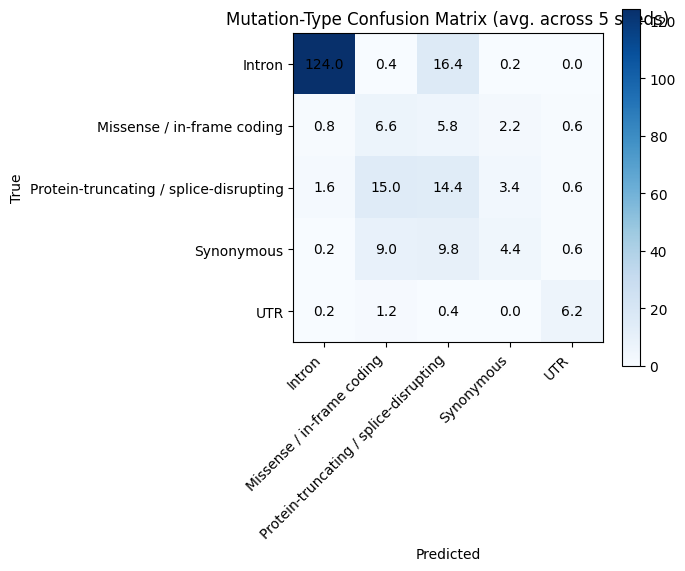

In [47]:
mut_df = pd.DataFrame(mtl_mut_results)
print("=== Mutation-Type Classification (MTL model) — mean ± std across 5 seeds ===")
print(mut_df[['accuracy', 'macro_f1']].agg(['mean', 'std']))

print("\nPer-class report (last seed, as an example):")
print(pd.DataFrame(last_mut_eval['report']).T)

avg_mut_cm = np.mean(mtl_mut_cms, axis=0)
plt.figure(figsize=(7, 6))
plt.imshow(avg_mut_cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Mutation-Type Confusion Matrix (avg. across 5 seeds)')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{avg_mut_cm[i, j]:.1f}", ha='center', va='center')
plt.tight_layout()
plt.savefig("mutation_type_confusion_matrix.png", dpi=300); plt.show()


### Aggregate C — per-mutation-class pathogenicity comparison

In [48]:
per_class_df = pd.DataFrame(per_class_patho_records)
summary_c = per_class_df.groupby('mutation_type').agg(
    n_test_avg=('n_test', 'mean'),
    baseline_auroc_mean=('baseline_auroc', 'mean'), baseline_auroc_std=('baseline_auroc', 'std'),
    mtl_auroc_mean=('mtl_auroc', 'mean'), mtl_auroc_std=('mtl_auroc', 'std'),
    baseline_f1_mean=('baseline_f1', 'mean'), mtl_f1_mean=('mtl_f1', 'mean'),
).reset_index()

print(summary_c)
summary_c.to_csv("per_mutation_class_pathogenicity_comparison.csv", index=False)
print("\nNote: treat classes with n_test_avg < ~15-20 as unreliable/directional only (esp. UTR).")


                            mutation_type  n_test_avg  baseline_auroc_mean  \
0                                  Intron       141.0             0.857664   
1              Missense / in-frame coding        16.0             0.679167   
2  Protein-truncating / splice-disrupting        35.0                  NaN   
3                              Synonymous        24.0                  NaN   
4                                     UTR         8.0                  NaN   

   baseline_auroc_std  mtl_auroc_mean  mtl_auroc_std  baseline_f1_mean  \
0            0.026632        0.883212       0.028534          0.146032   
1            0.060020        0.537500       0.098160          0.773449   
2                 NaN             NaN            NaN          0.831705   
3                 NaN             NaN            NaN          0.000000   
4                 NaN             NaN            NaN          0.986667   

   mtl_f1_mean  
0     0.120843  
1     0.836063  
2     0.972851  
3     0.000000  
4

### Aggregate E — baseline vs. MTL pathogenicity confusion matrices

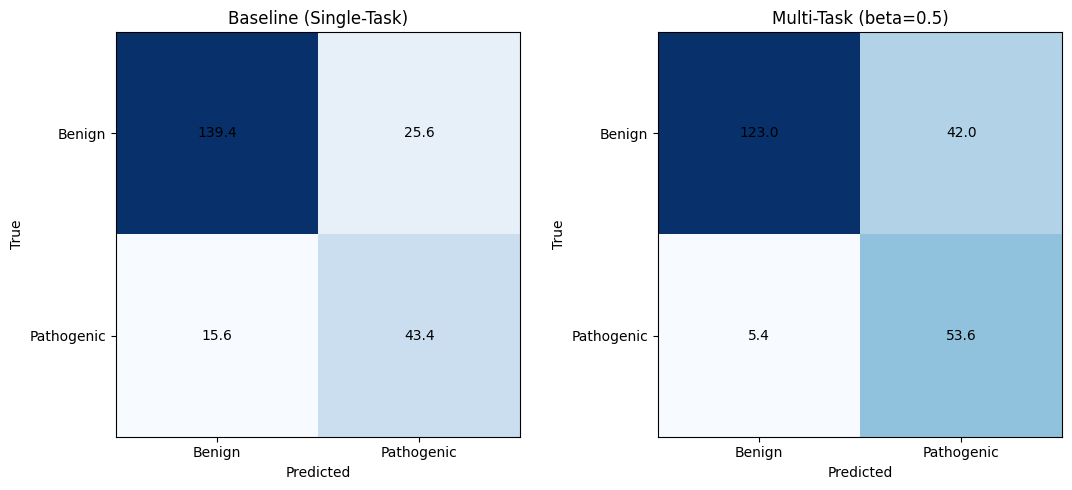

Baseline avg confusion matrix [rows=true, cols=pred (Benign, Pathogenic)]:
 [[139.4  25.6]
 [ 15.6  43.4]]

MTL avg confusion matrix:
 [[123.   42. ]
 [  5.4  53.6]]


In [49]:
avg_base_cm = np.mean(baseline_cms, axis=0)
avg_mtl_cm = np.mean(mtl_cms, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, cm, title in zip(axes, [avg_base_cm, avg_mtl_cm],
                          ['Baseline (Single-Task)', f'Multi-Task (beta={BEST_BETA})']):
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Benign', 'Pathogenic'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Benign', 'Pathogenic'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:.1f}", ha='center', va='center')
plt.tight_layout()
plt.savefig("pathogenicity_confusion_matrices_baseline_vs_mtl.png", dpi=300); plt.show()

print("Baseline avg confusion matrix [rows=true, cols=pred (Benign, Pathogenic)]:\n", avg_base_cm)
print("\nMTL avg confusion matrix:\n", avg_mtl_cm)
